# Reproduce everything

Regenerates every figure quoted in the paper, the README and `docs/guarantees.md`,
and asserts the ones the argument depends on. Run top to bottom.

**Kernel.** Use the comparison environment built by
`benchmarks/independent/setup_env.sh`, which pins scikit-learn 1.7.2 and
numpy 1.26.4. Those pins are required by `autofeat`, not by `beamfeat`;
section 1 checks `beamfeat` separately against the current releases.

**Runtime.** 15-30 minutes, dominated by the two `autofeat` suites.

**Not included.** The independent comparison study has its own notebook,
`benchmarks/independent/beamfeat_benchmark.ipynb`, with a `FULL_RUN` switch.
Its full recomputation takes a further 45-70 minutes.

## 0. Environment

In [1]:
import getpass, json, os, pathlib, platform, subprocess, sys, tempfile, time

ROOT = pathlib.Path.cwd()
if ROOT.name == "benchmarks":
    ROOT = ROOT.parent
BENCH = ROOT / "benchmarks"
sys.path.insert(0, str(BENCH))

import importlib.metadata as md
import importlib.util

print(f"python       {sys.version.split()[0]}")
print(f"platform     {platform.platform()}")
print(f"cpu count    {os.cpu_count()}")
for name in ("numpy", "scipy", "scikit-learn", "pandas", "lightgbm",
             "autofeat", "openfe", "knockpy", "beamfeat"):
    try:
        print(f"{name:<13} {md.version(name)}")
    except md.PackageNotFoundError:
        print(f"{name:<13} MISSING")
print(f"interpreter  {sys.executable}")

missing = [p for p in ("beamfeat", "lightgbm", "autofeat", "openfe", "knockpy")
           if importlib.util.find_spec(p) is None]
if missing:
    raise SystemExit(
        f"missing: {missing}. Build the comparison environment first:\n"
        "    conda create -n af315 python=3.11 -y && conda activate af315\n"
        "    bash benchmarks/independent/setup_env.sh")

python       3.11.15
platform     Linux-7.0.0-28-generic-x86_64-with-glibc2.39
cpu count    22
numpy         1.26.4
scipy         1.17.1
scikit-learn  1.7.2
pandas        2.3.3
lightgbm      4.7.0
autofeat      2.1.3
openfe        0.0.12
knockpy       1.3.2
beamfeat      0.2.0
interpreter  /home/dara/miniconda3/envs/af315/bin/python


## 1. Compatibility with current releases

The kernel above is pinned old for `autofeat`'s sake. `beamfeat` declares no
upper bounds, so the suite is also run against the newest numpy and
scikit-learn in a throwaway virtual environment. This is the evidence behind
the claim that the package installs and passes on current releases.

Requires network access. Set `CURRENT_STACK = None` to skip.

In [2]:
# Per-user path inside the platform temp directory: /tmp is Unix-only, and a
# fixed name collides between users on a shared machine.
CURRENT_STACK = (pathlib.Path(tempfile.gettempdir())
                 / f"beamfeat-current-stack-{getpass.getuser()}")

if CURRENT_STACK is None:
    print("skipped")
else:
    windows = os.name == "nt"
    bindir = CURRENT_STACK / ("Scripts" if windows else "bin")
    py = str(bindir / ("python.exe" if windows else "python"))
    pip = str(bindir / ("pip.exe" if windows else "pip"))

    if not bindir.exists():
        subprocess.run([sys.executable, "-m", "venv", str(CURRENT_STACK)], check=True)
        subprocess.run([pip, "install", "-q", "-U",
                        "numpy", "scikit-learn", "pytest", "pytest-cov", "pint", "sympy"],
                       check=True)
        subprocess.run([pip, "install", "-q", "-e", str(ROOT), "--no-deps"], check=True)

    print(subprocess.run([py, "-c",
        "import sklearn, numpy; print('resolved:', 'scikit-learn', sklearn.__version__, "
        "'| numpy', numpy.__version__)"], capture_output=True, text=True).stdout, end="")

    proc = subprocess.run([py, "-m", "pytest", "-q", str(ROOT / "tests")],
                          capture_output=True, text=True, cwd=ROOT)
    print(proc.stdout.strip().splitlines()[-1])
    assert proc.returncode == 0, "suite failed on the current stack"

resolved: scikit-learn 1.9.0 | numpy 2.4.6


370 passed, 6 warnings in 27.64s


## 2. Test suite

All 370 tests, including scikit-learn's `check_estimator` conformance suite,
with coverage.

In [3]:
proc = subprocess.run([sys.executable, "-m", "pytest", "-q",
                       "--cov=beamfeat", "--cov-report=term", str(ROOT / "tests")],
                      capture_output=True, text=True, cwd=ROOT)
tail = proc.stdout.strip().splitlines()
print("\n".join(tail[-12:]))
assert proc.returncode == 0, "test suite failed"


Name                                                                                   Stmts   Miss  Cover
----------------------------------------------------------------------------------------------------------
/home/dara/miniconda3/envs/af315/lib/python3.11/site-packages/beamfeat/__init__.py         7      0   100%
/home/dara/miniconda3/envs/af315/lib/python3.11/site-packages/beamfeat/estimators.py     386     34    91%
/home/dara/miniconda3/envs/af315/lib/python3.11/site-packages/beamfeat/expression.py     444     28    94%
/home/dara/miniconda3/envs/af315/lib/python3.11/site-packages/beamfeat/scoring.py        217      8    96%
/home/dara/miniconda3/envs/af315/lib/python3.11/site-packages/beamfeat/search.py         210     14    93%
/home/dara/miniconda3/envs/af315/lib/python3.11/site-packages/beamfeat/selection.py      302      7    98%
----------------------------------------------------------------------------------------------------------
TOTAL                               

## 3. End-to-end FDR calibration

200 replicates with signal at nominal FDR 0.10, then 60 with no signal at all.

In [4]:
import calibration_study

# The script checks the realised FDR against the level it ran at, for both the
# signal and global-null arms, and fails if either exceeds it.
calibration = calibration_study.main()

SIGNAL (200 replicates, nominal 0.10): empirical FDR 0.0000 (95% upper bound 0.0149) | power 1.000 | fallbacks 0
GLOBAL NULL (60 replicates): selections 0 (95% upper bound on the per-trial rate 0.0487)


## 4. Selector-level calibration

Realised FDR against the bound each correction must respect, with Monte Carlo
error, plus the two fixed-X knockoff offsets and the global-null stress behind
the Benjamini-Yekutieli default. Benjamini-Hochberg's bound is `q * m0/m`,
derived from the design rather than written in.

In [5]:
import selector_calibration

# The script derives each procedure's bound from the design and raises if a
# realised rate sits above it, so there is nothing to assert here.
selector = selector_calibration.main()

Permutation selector, 100 trials, Gaussian design 300x25 with 5 signals
  corr  nominal  realised      SE             95% CI   bound  power  ok


    BH     0.05    0.0464  0.0084 [ 0.0300, 0.0628]   0.040   1.00  y


    BH     0.10    0.0839  0.0120 [ 0.0604, 0.1073]   0.080   1.00  y


    BH     0.20    0.1607  0.0159 [ 0.1296, 0.1918]   0.160   1.00  y


    BY     0.05    0.0083  0.0037 [ 0.0012, 0.0155]   0.050   1.00  y


...

    BY     0.20    0.0464  0.0084 [ 0.0300, 0.0628]   0.200   1.00  y

Fixed-X knockoffs at nominal 0.20 (100 trials, same designs)
      offset  realised   power   controls


           1     0.159    1.00   FDR (knockoff+)


           0     0.249    1.00   modified FDR only

Global-null stress on the full pipeline (100 trials, no signal)
  correction  trials selecting  mean FDP


          BH             6/100      0.06


          BY             1/100      0.01


## 5. Friedman #1 decomposition

Separates the representation oracle from the ceiling imposed by marginal
screening, and from what the pipeline achieves. Reported over six draws with a
standard deviation: the oracle and ceiling are least-squares fits and barely
move, while the pipeline's score shifts more as the search makes discrete
choices.

In [6]:
import friedman_decomposition

# The script checks the ordering the decomposition rests on and fails if it
# breaks, so there is nothing to assert against a recorded number here.
decomposition = friedman_decomposition.main()

Friedman #1 decomposition over 6 independent draws
   draw   oracle  ceiling  achieved  admitted by the marginal null
      0    0.964    0.875     0.784  ab, (ab)^2, d, e
      1    0.959    0.877     0.782  ab, (ab)^2, c^2, d, e
      2    0.960    0.873     0.782  ab, (ab)^2, c^2, d, e
      3    0.956    0.864     0.788  ab, (ab)^2, d, e
      4    0.960    0.882     0.754  ab, (ab)^2, c^2, d, e
      5    0.961    0.871     0.765  ab, (ab)^2, d, e

   mean    0.960    0.874     0.776
     sd    0.003    0.006     0.013

  lost to marginal screening: 0.086
  lost to the search:         0.098
  admitted at least once: (ab)^2, ab, c^2, d, e


## 6. Benchmark suites

Eight harness runs, each writing a `.csv` and a `.json` into `benchmarks/`.
The two `autofeat` suites account for most of the runtime. `autofeat` seeds no
internal subsampling, so its numbers differ between runs.

In [7]:
SUITES = [
    ("core suite",          ["--suite", "core", "--synthetic-only", "--methods", "ridge", "lightgbm", "beamfeat"], "results.csv"),
    ("all synthetic",       ["--suite", "all", "--synthetic-only", "--methods", "ridge", "lightgbm", "beamfeat"], "results_all.csv"),
    ("stress suite",        ["--suite", "robustness", "--synthetic-only", "--methods", "beamfeat", "openfe"], "results_robustness.csv"),
    ("real datasets",       ["--real-only", "--methods", "ridge", "lightgbm", "beamfeat"], "results_real.csv"),
    ("autofeat core",       ["--suite", "core", "--synthetic-only", "--methods", "autofeat"], "results_autofeat_venv.csv"),
    ("autofeat stress",     ["--suite", "robustness", "--synthetic-only", "--methods", "autofeat"], "results_autofeat_robustness.csv"),
    ("knockpy synthetic",   ["--suite", "all", "--synthetic-only", "--methods", "knockpy"], "results_knockpy.csv"),
    ("knockpy real",        ["--real-only", "--methods", "knockpy"], "results_knockpy_real.csv"),
]

started = time.perf_counter()
for label, args, out in SUITES:
    t0 = time.perf_counter()
    proc = subprocess.run([sys.executable, str(BENCH / "run_benchmarks.py"),
                           *args, "--output", str(BENCH / out)],
                          capture_output=True, text=True, cwd=ROOT)
    elapsed = time.perf_counter() - t0
    status = "ok" if proc.returncode == 0 else "FAILED"
    print(f"{label:<20} -> {out:<34} {status:<7} {elapsed:7.1f}s")
    if proc.returncode != 0:
        print(proc.stderr[-1500:])
        raise SystemExit(f"{label} failed")
print(f"{'total':<20}    {'':<34} {'':<7} {time.perf_counter() - started:7.1f}s")

core suite           -> results.csv                        ok          7.7s


all synthetic        -> results_all.csv                    ok         11.5s


stress suite         -> results_robustness.csv             ok         11.5s


real datasets        -> results_real.csv                   ok         37.6s


autofeat core        -> results_autofeat_venv.csv          ok        121.0s


autofeat stress      -> results_autofeat_robustness.csv    ok        104.0s


knockpy synthetic    -> results_knockpy.csv                ok          1.4s


knockpy real         -> results_knockpy_real.csv           ok          2.2s
total                                                                296.8s


## 7. Physics equation panel

Twelve equations at 0.1% noise, with and without the exponential operator
enabled. Rewrites `benchmarks/feynman_results.json`, so its timings become
those of the machine this runs on.

In [8]:
proc = subprocess.run([sys.executable, str(BENCH / "feynman_panel.py")],
                      capture_output=True, text=True, cwd=ROOT)
print("\n".join(l for l in proc.stdout.splitlines() if l.startswith("[") or "wrote" in l))
assert proc.returncode == 0

[default operators]  solved 10/12 (R^2>0.999)  exact-form 8  mean 0.6s/eq
[with exp enabled]  solved 10/12 (R^2>0.999)  exact-form 8  mean 0.6s/eq
wrote /home/dara/Downloads/beamFeat/beamFeat/benchmarks/feynman_results.json


## 8. False-feature rate

Derived from the files written above. The false-feature rate is averaged over
the stress datasets that declare their generating columns; `threshold_step`
does not, so it is excluded and `n` is reported alongside.

In [9]:
import pandas as pd

CORE10 = ["product", "ratio", "three_way", "log_linear", "sqrt_ratio", "quadratic",
          "inverse_square", "physics_kinetic", "sparse_10col", "purely_linear"]
STRESS = ["distractors_noise05", "distractors_noise25", "distractors_noise50",
          "threshold_step", "small_n120", "small_n240"]

frames = {p.name: pd.read_csv(p) for p in sorted(BENCH.glob("results*.csv"))}

print("mean R^2 on the ten formula-recovery problems, and mean fit time")
for name, d in frames.items():
    core = d[d.dataset.isin(CORE10)]
    for m in sorted(d.method.unique()):
        s = core[core.method == m]
        if len(s):
            print(f"  {name:<34} {m:<9} {s.r2.mean():.4f}   {d[d.method == m].fit_seconds.mean():.3f}s")

print("\nformula recovery")
for name, d in frames.items():
    for m in sorted(d.method.unique()):
        rec = d[d.method == m].recovered.dropna()
        if len(rec):
            print(f"  {name:<34} {m:<9} {int(rec.sum())}/{len(rec)}")

# Reported as counts as well as a mean: with five scoreable datasets the mean
# carries a standard error of order 0.1, so the count is the honest summary.
print("\nfalse-feature rate, stress suite")
for name, d in frames.items():
    for m in sorted(d.method.unique()):
        ff = d[(d.method == m) & (d.dataset.isin(STRESS))].false_feature_rate.dropna()
        if len(ff):
            hit = int((ff > 0).sum())
            se = ff.std(ddof=1) / len(ff) ** 0.5 if len(ff) > 1 else 0.0
            print(f"  {name:<34} {m:<9} {hit}/{len(ff)} datasets affected   "
                  f"mean {ff.mean():.3f} ± {se:.3f}   worst {ff.max():.3f}")

print("\nreal-dataset panel")
print(frames["results_real.csv"].pivot_table(index="dataset", columns="method",
                                             values="r2").round(4).to_string())

beamfeat_core = frames["results.csv"].query("method == 'beamfeat' and dataset in @CORE10")
assert beamfeat_core.recovered.dropna().all(), "a core-suite formula was not recovered"
assert frames["results.csv"].query("method == 'beamfeat'").fdr_ok.all(), "FDR guarantee not held"

mean R^2 on the ten formula-recovery problems, and mean fit time
  results.csv                        beamfeat  0.9989   0.248s
  results.csv                        lightgbm  0.9798   0.308s
  results.csv                        ridge     0.8442   0.001s
  results_all.csv                    beamfeat  0.9989   0.303s
  results_all.csv                    lightgbm  0.9798   0.282s
  results_all.csv                    ridge     0.8442   0.001s
  results_autofeat_venv.csv          autofeat  0.9961   9.901s
  results_knockpy.csv                knockpy   0.8450   0.014s

formula recovery
  results.csv                        beamfeat  10/10
  results_all.csv                    beamfeat  15/15
  results_autofeat_robustness.csv    autofeat  5/5
  results_autofeat_venv.csv          autofeat  8/10
  results_knockpy.csv                knockpy   0/15
  results_robustness.csv             beamfeat  5/5
  results_robustness.csv             openfe    0/5

false-feature rate, stress suite
  results_all.cs

## 9. Paper figures

Five vector PDFs written to `paper/figures/`

writing figures to /home/dara/Downloads/beamFeat/beamFeat/paper/figures
  wrote /home/dara/Downloads/beamFeat/beamFeat/paper/figures/fig_core_accuracy.pdf
  wrote /home/dara/Downloads/beamFeat/beamFeat/paper/figures/fig_false_feature_rate.pdf
  wrote /home/dara/Downloads/beamFeat/beamFeat/paper/figures/fig_fdr_calibration.pdf
  wrote /home/dara/Downloads/beamFeat/beamFeat/paper/figures/fig_real_datasets.pdf
  wrote /home/dara/Downloads/beamFeat/beamFeat/paper/figures/fig_worst_case.pdf
  wrote /home/dara/Downloads/beamFeat/beamFeat/paper/figures/fig_accuracy_vs_cost.pdf
  wrote /home/dara/Downloads/beamFeat/beamFeat/paper/figures/fig_fit_distribution.pdf
fig_core_accuracy


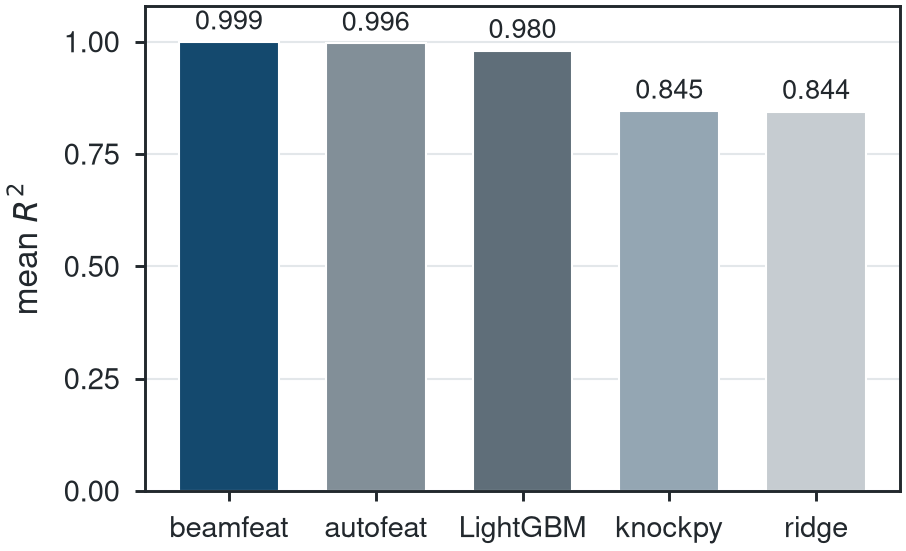

fig_false_feature_rate


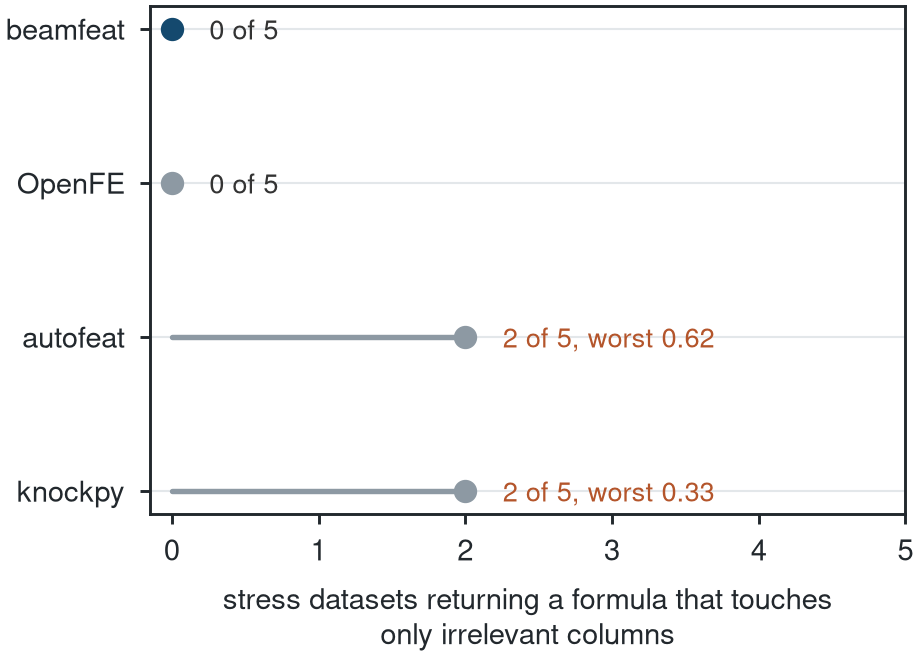

fig_fdr_calibration


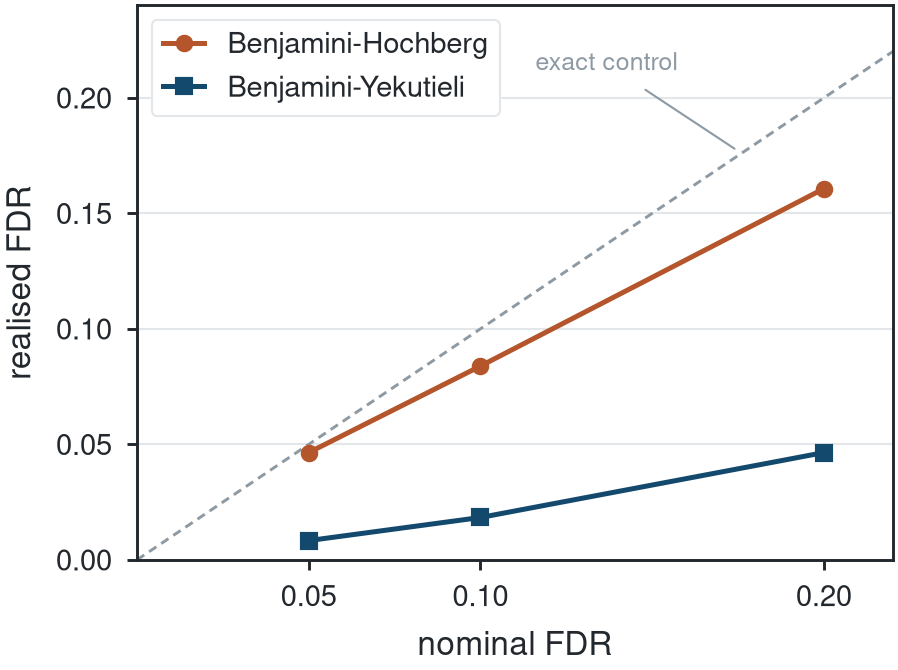

fig_real_datasets


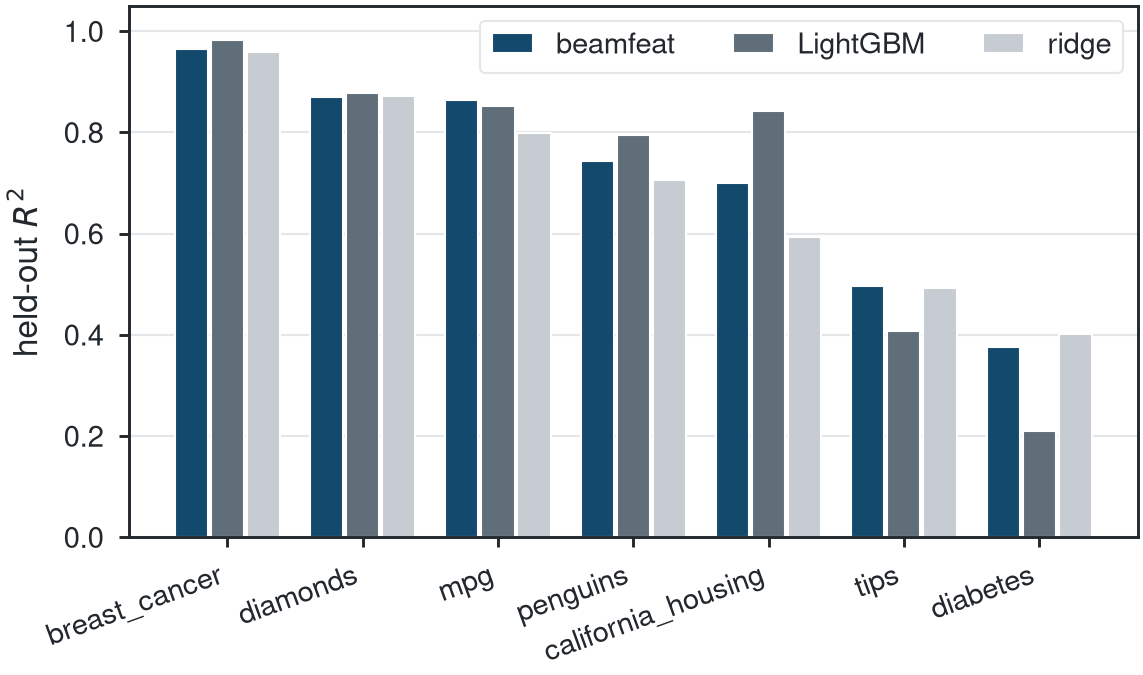

fig_worst_case


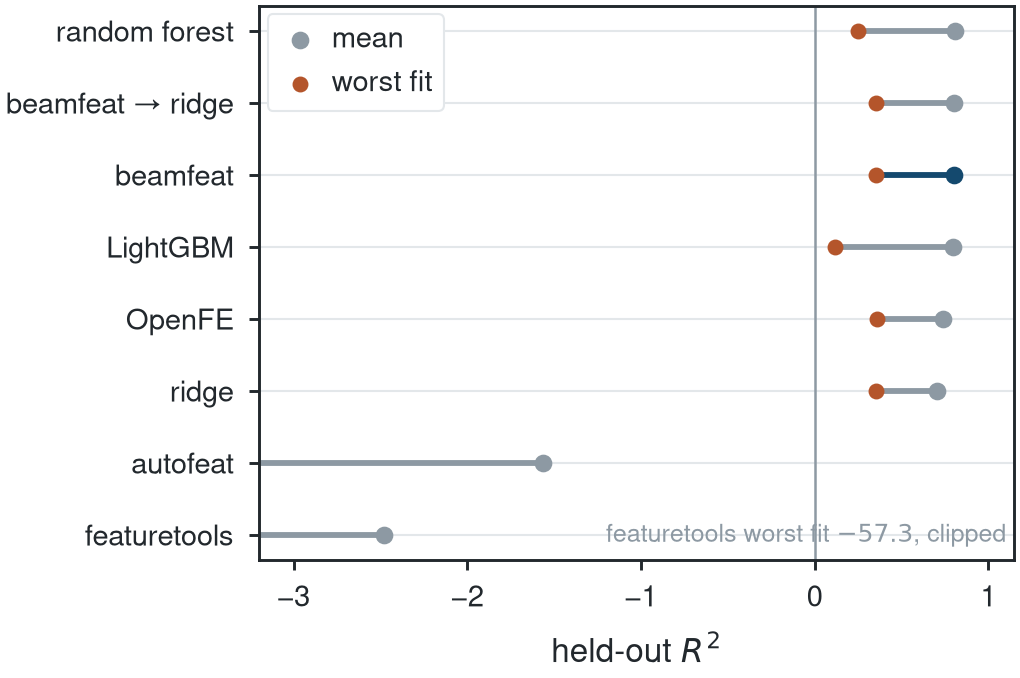

In [10]:
from IPython.display import Image, display

proc = subprocess.run([sys.executable, str(BENCH / "make_figures.py")],
                      capture_output=True, text=True, cwd=ROOT)
print("\n".join(l for l in proc.stdout.splitlines() if "wrote" in l or "writing" in l))
assert proc.returncode == 0

FIGURES = ROOT / "paper" / "figures"
for name in ("fig_core_accuracy", "fig_false_feature_rate", "fig_fdr_calibration",
             "fig_real_datasets", "fig_worst_case"):
    print(name)
    display(Image(filename=str(FIGURES / f"{name}.png"), width=460))

## 10. Independent comparison study

Not run here. Open `benchmarks/independent/beamfeat_benchmark.ipynb` with the
same kernel: it analyses the archived results in about two minutes, or
recomputes them in 15-70 minutes with `FULL_RUN = True`.